In [ ]:
from mace.calculators import MACECalculator
import torch
from ase.io import read
import torch
from calorine.tools import get_force_constants, relax_structure
import numpy as np
from ase.io import read
from ase import Atoms
from calorine.calculators import CPUNEP
from pandas import DataFrame
from phonopy.units import THzToCm
from seekpath import get_explicit_k_path
import phonopy
from ase.optimize import BFGS
from matplotlib import pyplot as plt
import warnings
import mplpub
mplpub.setup(template='acs')
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Disable LaTeX rendering to avoid LaTeX dependency issues
plt.rcParams['text.usetex'] = False

from calorine.tools import get_force_constants, relax_structure
from matplotlib import pyplot as plt
from phonopy.physical_units import get_physical_units
from seekpath import get_explicit_k_path

units = get_physical_units()

In [29]:
model_path = "/Users/prakriti/models/mace-mp-0b3-medium.model"

device = "cpu"
heads = ['omol']

for head in heads:
    calc = MACECalculator(model_paths=model_path,device=device,head=head,default_dtype="float32")

    atoms = read("/Users/prakriti/Downloads/quinBF4-out.cif")
    atoms.calc = calc
    print("Energy:", head, atoms.get_potential_energy())
    relax_structure(atoms, fmax=0.0001)
    print("Energy:", head, atoms.get_potential_energy())

/Users/prakriti/miniconda3/envs/mace/lib/python3.14/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Energy: omol -609.5811767578125
Energy: omol -611.2161865234375


In [30]:
structure_tuple = (atoms.cell, atoms.get_scaled_positions(), atoms.numbers)
path = get_explicit_k_path(structure_tuple)

In [31]:
phonon = get_force_constants(atoms, calc, [2, 2, 2])

In [32]:
phonon.run_band_structure([path['explicit_kpoints_rel']])
band = phonon.get_band_structure_dict()

In [33]:
df = DataFrame(band['frequencies'][0])
df.index = path['explicit_kpoints_linearcoord']

In [35]:
plt.rcParams["text.usetex"] = False

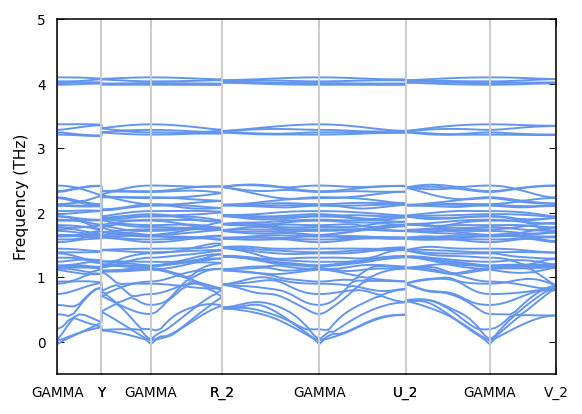

In [ ]:
fig, ax = plt.subplots(figsize=(4.2, 3), dpi=140)

for col in df.columns:
    ax.plot(df.index, df[col], color='cornflowerblue')
ax.set_xlim(df.index.min(), df.index.max())

ax.set_ylabel('Frequency (THz)')
#ax2 = ax.twinx()
#ax2.set_ylabel(r'Frequency (cm$^{-1}$)')
#ax2.set_ylim(units.THzToCm * np.array(ax.get_ylim()))

# beautify the labels on the x-axis
labels = path['explicit_kpoints_labels']
#labels = [r'$\Gamma$' if m == 'GAMMA' else m for m in labels]
#labels = [m.replace('_', '$_') + '$' if '_' in m else m for m in labels]
df_path = DataFrame(dict(labels=labels,
                         positions=path['explicit_kpoints_linearcoord']))
df_path.drop(df_path.index[df_path.labels == ''], axis=0, inplace=True)
ax.set_xticks(df_path.positions)
ax.set_xticklabels(df_path.labels)
for xp in df_path.positions:
    ax.axvline(xp, color='0.8')
ax.set_ylim(-0.5,5)
plt.tight_layout()
fig.savefig